In [1]:
import pandas as pd

In [107]:

df = pd.read_excel("/Users/irem/Downloads/lex.xlsx")
df.head()
df.columns

life_long = df.melt(
    id_vars=["geo", "name"],
    var_name="year",
    value_name="life_expectancy"
)
life_long["year"] = life_long["year"].astype(int)

In [108]:
gdp = pd.read_excel("/Users/irem/Downloads/gdp_pcap.xlsx")

gdp_long = gdp.melt(
    id_vars=["geo", "name"],   
    var_name="year",            
    value_name="gdp"           
)
gdp_long["year"] = gdp_long["year"].astype(int)


In [128]:

pop = pd.read_excel("/Users/irem/Downloads/pop.xlsx") 

pop_long = pop.melt(
    id_vars=["geo", "name"],
    var_name="year",
    value_name="population"
)
pop_long["year"] = pop_long["year"].astype(int)



In [131]:
merged = life_long.merge(gdp_long, on=["geo", "name", "year"])
merged_all = merged.merge(pop_long, on=["geo", "name", "year"])

In [132]:
merged_all.head() 

,geo,name,year,life_expectancy,gdp,population
0,afg,Afghanistan,1800,28.21,560.88817,3280000.0
1,ago,Angola,1800,26.98,435.23259,1567028.0
2,alb,Albania,1800,35.40,547.53369,400000.0
3,and,Andorra,1800,NaN,1598.53128,2654.0
4,are,UAE,1800,30.70,1332.77712,40153.0


In [133]:
merged_all.isnull().sum()

geo                   0
name                  0
year                  0
life_expectancy    1350
gdp                   0
population            0
dtype: int64

In [134]:
merged_all.isnull().mean() * 100

geo                0.00000
name               0.00000
year               0.00000
life_expectancy    2.32386
gdp                0.00000
population         0.00000
dtype: float64

In [135]:
merged_clean = merged_all.dropna(subset=["life_expectancy", "gdp"])

In [136]:
merged_all.head()       

,geo,name,year,life_expectancy,gdp,population
0,afg,Afghanistan,1800,28.21,560.88817,3280000.0
1,ago,Angola,1800,26.98,435.23259,1567028.0
2,alb,Albania,1800,35.40,547.53369,400000.0
3,and,Andorra,1800,NaN,1598.53128,2654.0
4,are,UAE,1800,30.70,1332.77712,40153.0


In [137]:
merged_all["population"].fillna(0)

0          3280000.0
1          1567028.0
2           400000.0
3             2654.0
4            40153.0
            ...     
58088       383557.0
58089    110035634.0
58090     94314448.0
58091     64473916.0
58092     37166572.0
Name: population, Length: 58093, dtype: float64

In [138]:
merged_all.head()       

,geo,name,year,life_expectancy,gdp,population
0,afg,Afghanistan,1800,28.21,560.88817,3280000.0
1,ago,Angola,1800,26.98,435.23259,1567028.0
2,alb,Albania,1800,35.40,547.53369,400000.0
3,and,Andorra,1800,NaN,1598.53128,2654.0
4,are,UAE,1800,30.70,1332.77712,40153.0


In [139]:
merged_all.head()

,geo,name,year,life_expectancy,gdp,population
0,afg,Afghanistan,1800,28.21,560.88817,3280000.0
1,ago,Angola,1800,26.98,435.23259,1567028.0
2,alb,Albania,1800,35.40,547.53369,400000.0
3,and,Andorra,1800,NaN,1598.53128,2654.0
4,are,UAE,1800,30.70,1332.77712,40153.0


In [140]:
merged_all.tail()

,geo,name,year,life_expectancy,gdp,population
58088,wsm,Samoa,2100,82.27,36317.37350,383557.0
58089,yem,Yemen,2100,82.08,8056.50777,110035634.0
58090,zaf,South Africa,2100,75.24,49804.86608,94314448.0
58091,zmb,Zambia,2100,74.48,24859.65796,64473916.0
58092,zwe,Zimbabwe,2100,71.32,22679.58974,37166572.0


In [141]:
merged_all["name"].value_counts()

name
Afghanistan          301
Liberia              301
Namibia              301
Niger                301
Nigeria              301
                    ... 
Equatorial Guinea    301
Greece               301
Grenada              301
Guatemala            301
Zimbabwe             301
Name: count, Length: 193, dtype: int64

In [142]:
data_1992 = merged_all[merged_all["year"] == 1992]

In [143]:
data_1992.head()

,geo,name,year,life_expectancy,gdp,population
37056,afg,Afghanistan,1992,54.24,2168.64015,13278974.0
37057,ago,Angola,1992,50.34,4750.38909,12423712.0
37058,alb,Albania,1992,73.23,3769.75645,3282501.0
37059,and,Andorra,1992,79.16,42769.13623,60200.0
37060,are,UAE,1992,68.78,75567.43966,2114730.0


In [144]:
continent_map = {
    'Afghanistan': 'Asia', 'Albania': 'Europe', 'Algeria': 'Africa', 'Angola': 'Africa',
    'Argentina': 'Americas', 'Armenia': 'Asia', 'Australia': 'Oceania', 'Austria': 'Europe',
    'Azerbaijan': 'Asia', 'Bahamas': 'Americas', 'Bahrain': 'Asia', 'Bangladesh': 'Asia',
    'Barbados': 'Americas', 'Belarus': 'Europe', 'Belgium': 'Europe', 'Belize': 'Americas',
    'Benin': 'Africa', 'Bhutan': 'Asia', 'Bolivia': 'Americas', 'Bosnia and Herzegovina': 'Europe',
    'Botswana': 'Africa', 'Brazil': 'Americas', 'Brunei': 'Asia', 'Bulgaria': 'Europe',
    'Burkina Faso': 'Africa', 'Burundi': 'Africa', 'Cambodia': 'Asia', 'Cameroon': 'Africa',
    'Canada': 'Americas', 'Cape Verde': 'Africa', 'Central African Republic': 'Africa',
    'Chad': 'Africa', 'Chile': 'Americas', 'China': 'Asia', 'Colombia': 'Americas',
    'Comoros': 'Africa', 'Congo, Dem. Rep.': 'Africa', 'Congo, Rep.': 'Africa',
    'Costa Rica': 'Americas', 'Croatia': 'Europe', 'Cuba': 'Americas', 'Cyprus': 'Asia',
    'Czech Republic': 'Europe', 'Denmark': 'Europe', 'Djibouti': 'Africa',
    'Dominican Republic': 'Americas', 'Ecuador': 'Americas', 'Egypt': 'Africa',
    'El Salvador': 'Americas', 'Equatorial Guinea': 'Africa', 'Eritrea': 'Africa',
    'Estonia': 'Europe', 'Ethiopia': 'Africa', 'Fiji': 'Oceania', 'Finland': 'Europe',
    'France': 'Europe', 'Gabon': 'Africa', 'Gambia': 'Africa', 'Georgia': 'Asia',
    'Germany': 'Europe', 'Ghana': 'Africa', 'Greece': 'Europe', 'Guatemala': 'Americas',
    'Guinea': 'Africa', 'Guinea-Bissau': 'Africa', 'Guyana': 'Americas', 'Haiti': 'Americas',
    'Honduras': 'Americas', 'Hungary': 'Europe', 'Iceland': 'Europe', 'India': 'Asia',
    'Indonesia': 'Asia', 'Iran': 'Asia', 'Iraq': 'Asia', 'Ireland': 'Europe',
    'Israel': 'Asia', 'Italy': 'Europe', 'Jamaica': 'Americas', 'Japan': 'Asia',
    'Jordan': 'Asia', 'Kazakhstan': 'Asia', 'Kenya': 'Africa', 'Kiribati': 'Oceania',
    'Kuwait': 'Asia', 'Kyrgyzstan': 'Asia', 'Laos': 'Asia', 'Latvia': 'Europe',
    'Lebanon': 'Asia', 'Lesotho': 'Africa', 'Liberia': 'Africa', 'Libya': 'Africa',
    'Lithuania': 'Europe', 'Luxembourg': 'Europe', 'Madagascar': 'Africa', 'Malawi': 'Africa',
    'Malaysia': 'Asia', 'Maldives': 'Asia', 'Mali': 'Africa', 'Malta': 'Europe',
    'Mauritania': 'Africa', 'Mauritius': 'Africa', 'Mexico': 'Americas', 'Moldova': 'Europe',
    'Mongolia': 'Asia', 'Montenegro': 'Europe', 'Morocco': 'Africa', 'Mozambique': 'Africa',
    'Myanmar': 'Asia', 'Namibia': 'Africa', 'Nepal': 'Asia', 'Netherlands': 'Europe',
    'New Zealand': 'Oceania', 'Nicaragua': 'Americas', 'Niger': 'Africa', 'Nigeria': 'Africa',
    'North Korea': 'Asia', 'Norway': 'Europe', 'Oman': 'Asia', 'Pakistan': 'Asia',
    'Panama': 'Americas', 'Papua New Guinea': 'Oceania', 'Paraguay': 'Americas',
    'Peru': 'Americas', 'Philippines': 'Asia', 'Poland': 'Europe', 'Portugal': 'Europe',
    'Qatar': 'Asia', 'Romania': 'Europe', 'Russia': 'Europe', 'Rwanda': 'Africa',
    'Saudi Arabia': 'Asia', 'Senegal': 'Africa', 'Serbia': 'Europe', 'Sierra Leone': 'Africa',
    'Singapore': 'Asia', 'Slovakia': 'Europe', 'Slovenia': 'Europe', 'Solomon Islands': 'Oceania',
    'Somalia': 'Africa', 'South Africa': 'Africa', 'South Korea': 'Asia', 'South Sudan': 'Africa',
    'Spain': 'Europe', 'Sri Lanka': 'Asia', 'Sudan': 'Africa', 'Suriname': 'Americas',
    'Sweden': 'Europe', 'Switzerland': 'Europe', 'Syria': 'Asia', 'Taiwan': 'Asia',
    'Tajikistan': 'Asia', 'Tanzania': 'Africa', 'Thailand': 'Asia', 'Timor-Leste': 'Asia',
    'Togo': 'Africa', 'Tonga': 'Oceania', 'Trinidad and Tobago': 'Americas', 'Tunisia': 'Africa',
    'Turkey': 'Asia', 'Uganda': 'Africa', 'Ukraine': 'Europe', 'United Arab Emirates': 'Asia',
    'United Kingdom': 'Europe', 'United States': 'Americas', 'Uruguay': 'Americas',
    'Uzbekistan': 'Asia', 'Vanuatu': 'Oceania', 'Venezuela': 'Americas', 'Vietnam': 'Asia',
    'Yemen': 'Asia', 'Zambia': 'Africa', 'Zimbabwe': 'Africa'
}
# I asked chatgbt to write a code to spesify the continents of the countries

In [145]:
merged_all["continent"] = merged_all["name"].map(continent_map)


In [146]:
asia = merged_all[merged_all["continent"] == "Asia"]


In [147]:
asia.head()

,geo,name,year,life_expectancy,gdp,population,continent
0,afg,Afghanistan,1800,28.21,560.88817,3280000.0,Asia
6,arm,Armenia,1800,34.00,686.42028,413326.0,Asia
10,aze,Azerbaijan,1800,29.17,845.58821,879960.0,Asia
15,bgd,Bangladesh,1800,25.50,900.12777,19191243.0,Asia
17,bhr,Bahrain,1800,30.30,996.21276,64474.0,Asia


In [148]:
pop_filtered = merged_all[merged_all["population"] < 1_000_000]


In [149]:
pop_filtered.head()

,geo,name,year,life_expectancy,gdp,population,continent
2,alb,Albania,1800,35.4,547.53369,400000.0,Europe
3,and,Andorra,1800,NaN,1598.53128,2654.0,NaN
4,are,UAE,1800,30.7,1332.77712,40153.0,NaN
5,arg,Argentina,1800,33.2,1981.80486,534000.0,Americas
6,arm,Armenia,1800,34.0,686.42028,413326.0,Asia


In [150]:
average_gdp = merged_all["gdp"].mean()
print("Average GDP:", average_gdp)


Average GDP: 15022.79444104298


In [155]:
average_gdp_by_continent = merged_all.groupby("continent")["gdp"].mean().reset_index()
average_gdp_by_continent

,continent,gdp
0,Africa,5439.975321
1,Americas,14629.844788
2,Asia,15676.568620
3,Europe,25585.829885
4,Oceania,11334.181412


In [160]:
highest_life_expectancy = merged_all[merged_all["life_expectancy"] == merged_all["life_expectancy"].max()]
highest_life_expectancy[["continent", "name", "life_expectancy"]]

,continent,name,life_expectancy
58051,Asia,Singapore,94.78


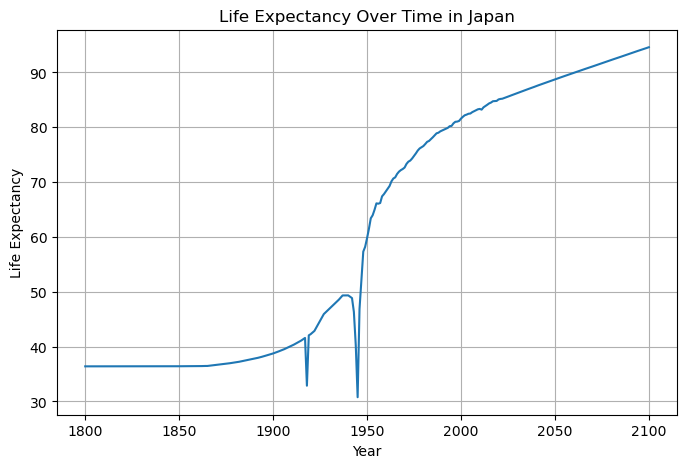

In [167]:
import matplotlib.pyplot as plt

Geogia = merged_all[merged_all["name"] == "Georgia"]

plt.figure(figsize=(8,5))
plt.plot(japan["year"], japan["life_expectancy"], marker='')
plt.title("Life Expectancy Over Time in Japan")
plt.xlabel("Year")
plt.ylabel("Life Expectancy")
plt.grid(True)
plt.show()


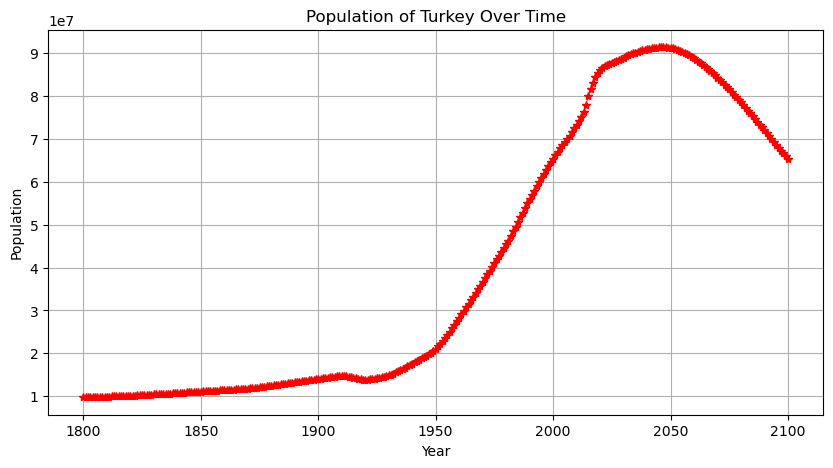

In [185]:
turkey = merged_all[merged_all["name"] == "Turkey"]

import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(
    turkey["year"], 
    turkey["population"], 
    color='r', 
    marker='*', 
    linewidth= 0.5
)
plt.title("Population of Turkey Over Time")
plt.xlabel("Year")
plt.ylabel("Population")
plt.grid(True)
plt.show()
